# Custom algorithm approach 2

This notebook explores the use of an altenative algorithm to generate ontologies based on the conclusion from naive approach.

We will explore the definition of comunities.

In [6]:
%load_ext autoreload
%autoreload 2

## Libraries
import sys
from pathlib import Path
import pandas as pd
import json
import math
import numpy as np
import community as community_louvain
import matplotlib.pyplot as plt
import networkx as nx

sys.path.insert(0, str(Path.cwd().parent))
from src.services import ChatGpt
from src.services import clustering


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
## Setup parameters

domain = "Star Trek"
initial_term_seed = 20
similarity_filter = 80 # cuts the relationships that count from similarity taxonomy
minimum_confidence_treshold = 0.85

ucb1_exploration_constant = 2
k_similarity_treshold = 80
g_min_reward_treshold = 10
max_iterations = 10


---
## Step 1 - seeds

Get first batch (seed) and calculate similarities

In [8]:
agent = ChatGpt()
agent.model = "gpt-4o-mini"


In [9]:
terms_list_str = agent.chat(
    instructions="You are a taxonomy and ontology expert. Provide concise and accurate responses based on the user's queries.",
    input=f"""
        Provide a list of {initial_term_seed} categories, terms or words closely related to domain or topic and using the provided terms as reference.
        
        - the domain or topic is: {domain}
        
        Your output should be a json array with only the category names, with a small text describing the term and relation to theme. 
        This categories should include the given terms and be closely related to the domain or topic.
        Do not encapsulate the output in code blocks.
        
        Example output:
        [
            "category1": "small description1",
            "category2": "small description12",
            ...            "category100":"small description100"
        ]
        
    """
)

In [10]:
terms_list_json = json.loads(terms_list_str)
terms_list_flat = [(list(d.keys())[0], list(d.values())[0]) for d in terms_list_json]
terms_list_df = pd.DataFrame(terms_list_flat, columns=["term", "description"])

In [11]:
terms_pair = pd.merge(terms_list_df, terms_list_df, how='cross')
terms_pair = terms_pair.drop(terms_pair[terms_pair['term_x'] == terms_pair['term_y']].index) # We don't need to analyse a term with itself

In [12]:
terms_pair['similarity'] = terms_pair.apply(
    lambda row: agent.get_similarity_with_descriptions(
        term_x=row['term_x'],
        description_x=row['description_x'],
        term_y=row['term_y'],
        description_y=row['description_y']
    )['similarity'],
    axis=1
)

---
## Step 2: Generate Semantic Similarity Graph and detect initial communities 

In [13]:
terms_pair

,term_x,description_x,term_y,description_y,similarity
1,Starfleet,The scientific and exploratory space service o...,Klingons,A prominent warrior species known for their ho...,70
2,Starfleet,The scientific and exploratory space service o...,Borg,A collective species that assimilates other sp...,75
3,Starfleet,The scientific and exploratory space service o...,Federation,An interstellar political entity comprised of ...,80
4,Starfleet,The scientific and exploratory space service o...,Warp Drive,A faster-than-light propulsion system used for...,70
5,Starfleet,The scientific and exploratory space service o...,Phaser,A directed-energy weapon commonly used by Star...,70
...,...,...,...,...,...
394,Temporal Prime Directive,A guideline governing time travel to prevent t...,Trekking,"The act of exploring space, often associated w...",20
395,Temporal Prime Directive,A guideline governing time travel to prevent t...,Transporter,A device that beams individuals or objects fro...,30
396,Temporal Prime Directive,A guideline governing time travel to prevent t...,Q Continuum,A powerful group of omnipotent beings that man...,30
397,Temporal Prime Directive,A guideline governing time travel to prevent t...,Neighbors: The Sisko,A powerful being who explores identity and exi...,20


In [14]:

similarity_graph = clustering.build_similarity_graph(terms_pair, similarity_filter)
#similarity_graph['distance'] = 100 - similarity_graph['similarity']

All terms (20): ['Androids', 'Borg', 'Captain', 'Cardassians', 'Federation', 'Holodeck', 'Klingons', 'Neighbors: The Sisko', 'Phaser', 'Q Continuum', 'Romulans', 'Starfleet', 'Starship Enterprise', 'Temporal Mechanics', 'Temporal Prime Directive', 'Transporter', 'Trekking', 'Tribbles', 'Vulcans', 'Warp Drive']

Edges added (threshold >= 80):
  Trekking -- Starfleet (weight: 80.00)
  Trekking -- Starship Enterprise (weight: 85.00)
  Neighbors: The Sisko -- Q Continuum (weight: 85.00)
  Captain -- Starfleet (weight: 80.00)
  Captain -- Starship Enterprise (weight: 80.00)
  Starship Enterprise -- Starfleet (weight: 80.00)
  Starfleet -- Federation (weight: 85.00)
  Cardassians -- Klingons (weight: 80.00)
  Temporal Mechanics -- Temporal Prime Directive (weight: 80.00)

Summary: 20 nodes, 9 edges


In [15]:
len(similarity_graph)

20

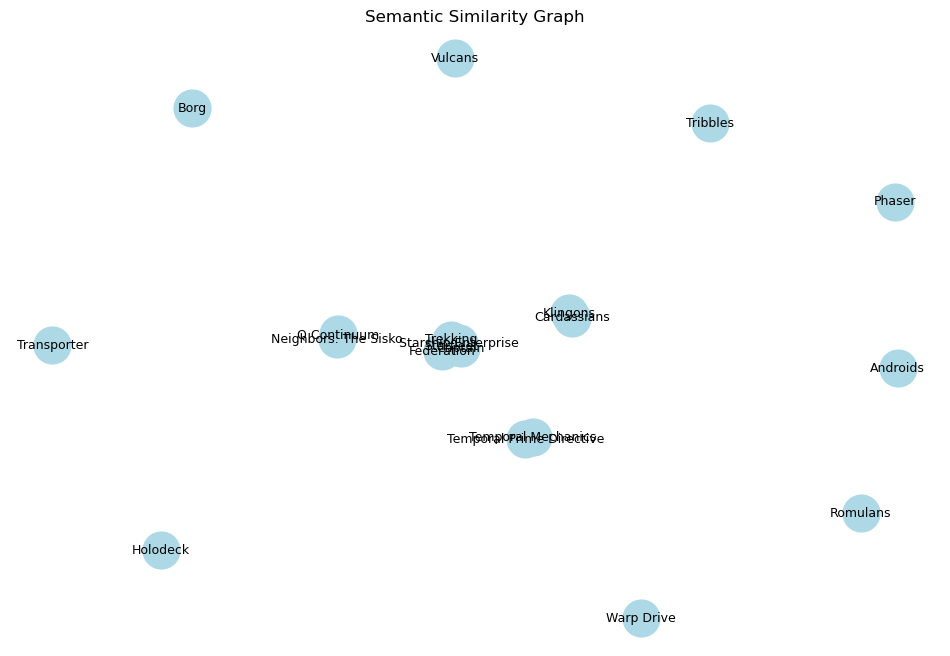

In [16]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(similarity_graph, seed=42) 
nx.draw_networkx_nodes(similarity_graph, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(similarity_graph, pos, width=1.0, alpha=0.7)
nx.draw_networkx_labels(similarity_graph, pos, font_size=9, font_family="sans-serif")
plt.title("Semantic Similarity Graph")
plt.axis('off')
plt.show()

In [17]:
communities = community_louvain.best_partition(similarity_graph, weight='weight')

# Print communities
for community_id in set(communities.values()):
    members = [node for node, cid in communities.items() if cid == community_id]
    print(f"Community {community_id}: {members}")

Community 0: ['Vulcans']
Community 1: ['Transporter']
Community 2: ['Neighbors: The Sisko', 'Q Continuum']
Community 3: ['Temporal Mechanics', 'Temporal Prime Directive']
Community 4: ['Tribbles']
Community 5: ['Borg']
Community 6: ['Romulans']
Community 7: ['Holodeck']
Community 8: ['Trekking', 'Captain', 'Starship Enterprise', 'Starfleet', 'Federation']
Community 9: ['Phaser']
Community 10: ['Warp Drive']
Community 11: ['Cardassians', 'Klingons']
Community 12: ['Androids']


---
## Step 3: Infer initial ontology

In [18]:
import json
import re

def induce_local_ontology(communities, terms_list_df, agent, domain, minimum_confidence_threshold=0.95):
    """
    Induce local ontology by classifying relationships between terms in communities.
    
    Args:
        communities: Dict mapping terms to community IDs
        terms_list_df: DataFrame with 'term' and 'description' columns
        agent: Chat agent for LLM interaction
        domain: The domain context (e.g., "software engineering", "biology")
        minimum_confidence_threshold: Minimum confidence for including relations (0-1)
    """
    # Group terms by community
    grouped_communities = {}
    for term, cid in communities.items():
        grouped_communities.setdefault(cid, []).append(term)

    results = {}

    for cid, terms in grouped_communities.items():
        print(f"\nProcessing community {cid} with {len(terms)} terms...")
        
        # Skip communities with only 1 term (no pairs to compare)
        if len(terms) < 2:
            print(f"Skipping community {cid}: only {len(terms)} term(s)")
            results[cid] = []
            continue
        
        # Fetch descriptions
        descs = []
        for term in terms:
            desc = terms_list_df.loc[terms_list_df['term'] == term, 'description'].values
            if len(desc) > 0:
                descs.append(f"- {term}: {desc[0]}")
            else:
                descs.append(f"- {term}: [No description found]")

        # Convert threshold to percentage for clarity
        threshold_pct = minimum_confidence_threshold * 100

        prompt = f"""You are a domain expert in {domain}. Your task is to classify relationships between pairs of DIFFERENT terms based STRICTLY on the definitions below.

DOMAIN CONTEXT: {domain}

RELATIONSHIP DEFINITIONS (use ONLY these three categories):

1. SIMILARITY: Terms represent equivalent, analogous, or interchangeable concepts within {domain}.
   - They describe the same or very similar phenomena
   - They could be synonyms, near-synonyms, or alternate names
   - They belong to the same group/concept
   - Example: "vehicle" and "automobile"

2. COMPOSITION: One term is a structural component, part, or element of the other within {domain}.
   - Clear part-whole relationship (X is part of Y)
   - Hierarchical containment (X belongs to Y)
   - NOT similarity, NOT metaphorical relationships
   - Example: "engine" is composition of "car"

3. NO RELATION: Terms have no meaningful similarity or compositional relationship in {domain}.
   - They are distinct concepts
   - No direct structural or semantic connection
   - Default classification when uncertain

TERMS TO ANALYZE:
{chr(10).join(descs)}

CLASSIFICATION RULES:
- Analyze ONLY the terms provided above (do not invent terms)
- Evaluate each unique pair exactly once
- **NEVER compare a term with itself** (source must differ from target)
- Consider the {domain} context for all classifications
- Use "no relation" as the default when uncertain
- Base classifications on the provided descriptions

OUTPUT REQUIREMENTS:
- Return ONLY a valid JSON array, nothing else
- No markdown code blocks, no explanations, no preamble
- Start directly with [ and end with ]
- Include ALL pairs between DIFFERENT terms (even "no relation" pairs)
- **Exclude any pair where source equals target**
- Confidence must be between 0 and 100 (as percentage)

JSON FORMAT:
[
    {{
        "source": "exact_term_from_list",
        "target": "different_exact_term_from_list",
        "relation": "similarity",
        "confidence": 85.5,
        "justification": "Brief explanation in {domain} context"
    }}
]

CRITICAL: Do NOT include pairs like {{"source": "X", "target": "X"}}. Always ensure source ≠ target.

Start your response with [ and output valid JSON only."""

        response = agent.chat(
            instructions=f"You are a {domain} expert. Output ONLY valid JSON array comparing DIFFERENT terms. No self-comparisons. No markdown, no explanations. Start with [ character.",
            input=prompt
        )
        
        # Debug: print raw response
        print(f"Raw response length: {len(response)} chars")
        print(f"First 200 chars: {response[:200]}")
        
        try:
            # Clean the response - remove markdown code blocks if present
            cleaned_response = response.strip()
            
            # Remove markdown code blocks
            if cleaned_response.startswith("```"):
                # Extract content between ```json and ``` or ``` and ```
                match = re.search(r'```(?:json)?\s*(\[.*?\])\s*```', cleaned_response, re.DOTALL)
                if match:
                    cleaned_response = match.group(1)
                else:
                    # Try removing first and last lines
                    lines = cleaned_response.split('\n')
                    cleaned_response = '\n'.join(lines[1:-1])
            
            # Find the JSON array in the response
            start_idx = cleaned_response.find('[')
            end_idx = cleaned_response.rfind(']')
            
            if start_idx == -1 or end_idx == -1:
                print(f"Warning: No JSON array found in response for community {cid}")
                print(f"Response: {cleaned_response[:500]}")
                results[cid] = []
                continue
            
            json_str = cleaned_response[start_idx:end_idx + 1]
            relations = json.loads(json_str)
            
            # Validation and filtering
            valid_relations = []
            for rel in relations:
                # Validate structure
                if not all(key in rel for key in ["source", "target", "relation", "confidence"]):
                    print(f"Warning: Skipping relation due to missing keys: {rel}")
                    continue
                
                # CRITICAL: Skip self-comparisons
                if rel["source"] == rel["target"]:
                    print(f"Warning: Skipping self-comparison: {rel['source']} -> {rel['target']}")
                    continue
                
                # Validate terms exist in the original list
                if rel["source"] not in terms or rel["target"] not in terms:
                    print(f"Warning: Skipping relation with unknown terms: {rel['source']} -> {rel['target']}")
                    continue
                
                # Normalize confidence (handle both 0-1 and 0-100 scales)
                confidence = rel.get("confidence", 0)
                if confidence <= 1.0:
                    confidence = confidence * 100  # Convert 0-1 to 0-100
                
                # Validate relation type
                relation_type = (rel.get("relation") or "").lower().strip()
                if relation_type not in ["similarity", "composition", "no relation"]:
                    print(f"Warning: Invalid relation type '{relation_type}' for {rel['source']} -> {rel['target']}")
                    continue
                
                # Filter by confidence and exclude "no relation"
                if confidence >= threshold_pct and relation_type != "no relation":
                    rel["confidence"] = confidence  # Store normalized confidence
                    rel["relation"] = relation_type  # Store normalized relation
                    valid_relations.append(rel)
            
            print(f"Community {cid}: Found {len(relations)} total pairs, {len(valid_relations)} valid after filtering")
            results[cid] = valid_relations
            
        except json.JSONDecodeError as e:
            print(f"Warning: Failed to parse JSON for community {cid}: {e}")
            print(f"Attempted to parse: {json_str[:500] if 'json_str' in locals() else cleaned_response[:500]}")
            results[cid] = []
        except Exception as e:
            print(f"Warning: Error processing community {cid}: {e}")
            import traceback
            traceback.print_exc()
            results[cid] = []

    return results

In [19]:
local_ontologies = induce_local_ontology(communities, terms_list_df, agent, domain, minimum_confidence_treshold)
print(json.dumps(local_ontologies, indent=2))


Processing community 0 with 1 terms...
Skipping community 0: only 1 term(s)

Processing community 8 with 5 terms...
Raw response length: 2393 chars
First 200 chars: [
    {
        "source": "Trekking",
        "target": "Starship Enterprise",
        "relation": "no relation",
        "confidence": 95.0,
        "justification": "Trekking refers to the act of ex
Community 8: Found 10 total pairs, 4 valid after filtering

Processing community 2 with 2 terms...
Raw response length: 277 chars
First 200 chars: [
    {
        "source": "Neighbors: The Sisko",
        "target": "Q Continuum",
        "relation": "no relation",
        "confidence": 95,
        "justification": "The Sisko explores identity wh
Community 2: Found 1 total pairs, 0 valid after filtering

Processing community 4 with 1 terms...
Skipping community 4: only 1 term(s)

Processing community 6 with 1 terms...
Skipping community 6: only 1 term(s)

Processing community 7 with 1 terms...
Skipping community 7: only 1 term

In [20]:
print(json.dumps(local_ontologies, indent=2))

{
  "0": [],
  "8": [
    {
      "source": "Captain",
      "target": "Starship Enterprise",
      "relation": "composition",
      "confidence": 92.0,
      "justification": "The Captain commands the Starship Enterprise."
    },
    {
      "source": "Captain",
      "target": "Starfleet",
      "relation": "composition",
      "confidence": 90.0,
      "justification": "The rank of Captain exists within the structure of Starfleet."
    },
    {
      "source": "Starship Enterprise",
      "target": "Starfleet",
      "relation": "composition",
      "confidence": 95.0,
      "justification": "The Starship Enterprise is part of Starfleet."
    },
    {
      "source": "Starfleet",
      "target": "Federation",
      "relation": "similarity",
      "confidence": 85.0,
      "justification": "Starfleet is a service of the Federation, highlighting their interconnectedness."
    }
  ],
  "2": [],
  "4": [],
  "6": [],
  "7": [],
  "10": [],
  "11": [],
  "1": [],
  "3": [],
  "5": [],
  

---
## Step 4: Explore and Exploit

In [21]:
import re

# def clean_and_parse_json(response):
#     """
#     Cleans LLM response string and parses JSON, handling markdown code blocks.
#     Returns parsed JSON or None if parsing fails.
    
#     NOTE: Only use this for LLM text responses, not for already-parsed dicts like local_ontologies.
#     """
#     try:
#         cleaned = response.strip()
        
#         # Remove markdown code blocks
#         if cleaned.startswith("```"):
#             match = re.search(r'```(?:json)?\s*(\[.*?\]|\{.*?\})\s*```', cleaned, re.DOTALL)
#             if match:
#                 cleaned = match.group(1)
#             else:
#                 lines = cleaned.split('\n')
#                 cleaned = '\n'.join(lines[1:-1])
        
#         # Find JSON in response
#         if cleaned.startswith('['):
#             start_idx = cleaned.find('[')
#             end_idx = cleaned.rfind(']')
#         else:
#             start_idx = cleaned.find('{')
#             end_idx = cleaned.rfind('}')
        
#         if start_idx == -1 or end_idx == -1:
#             return None
        
#         json_str = cleaned[start_idx:end_idx + 1]
#         return json.loads(json_str)
        
#     except Exception as e:
#         print(f"JSON parsing error: {e}")
#         return None

In [22]:
import json
import re
import math
import numpy as np
import pandas as pd
import networkx as nx
from collections import defaultdict


def clean_and_parse_json(response):
    """Parse JSON from LLM response, handling markdown wrappers."""
    cleaned = response.strip()

    if cleaned.startswith("```"):
        match = re.search(r"```(?:json)?\s*([\[{].*?[\]}])\s*```", cleaned, re.DOTALL)
        if match:
            cleaned = match.group(1)
        else:
            lines = cleaned.split("\n")
            cleaned = "\n".join(lines[1:-1])

    # Find the JSON structure
    start_array = cleaned.find("[")
    start_obj = cleaned.find("{")

    if start_array == -1 and start_obj == -1:
        return None

    # Pick whichever comes first
    if start_array == -1:
        start = start_obj
        end = cleaned.rfind("}")
    elif start_obj == -1:
        start = start_array
        end = cleaned.rfind("]")
    else:
        if start_array < start_obj:
            start = start_array
            end = cleaned.rfind("]")
        else:
            start = start_obj
            end = cleaned.rfind("}")

    if start == -1 or end == -1:
        return None

    try:
        return json.loads(cleaned[start : end + 1])
    except json.JSONDecodeError:
        return None

In [23]:
def build_ontology_graph(local_ontologies):
    """
    Builds a directed ontology graph from local_ontologies dict.
    Returns a NetworkX DiGraph with relation attributes.
    
    NOTE: local_ontologies is already a Python dict, no JSON parsing needed.
    """
    ontology = nx.DiGraph()
    
    for community_id, relations in local_ontologies.items():
        for rel in relations:
            source = rel['source']
            target = rel['target']
            relation_type = rel['relation']
            confidence = rel.get('confidence', 0)
            
            # Add nodes if they don't exist
            if not ontology.has_node(source):
                ontology.add_node(source)
            if not ontology.has_node(target):
                ontology.add_node(target)
            
            # Add edge with relation type and confidence
            ontology.add_edge(source, target, 
                            relation=relation_type, 
                            confidence=confidence,
                            justification=rel.get('justification', ''))
    
    return ontology

In [24]:
class OntologyExpander:
    """
    UCB1-guided iterative ontology expansion using LLM-based similarity.
    
    Uses agent.get_similarity_with_descriptions() instead of embeddings.
    """

    def __init__(
        self,
        G,
        ontology,
        partition,
        agent,
        domain,
        terms_df,
        similarity_threshold=80,
        confidence_threshold=60,
        n_candidates=20,
        exploration_constant=2.0,
    ):
        """
        Args:
            G: networkx.Graph - similarity graph (undirected, weighted edges)
            ontology: networkx.DiGraph - ontology graph (directed, typed edges)
            partition: dict mapping term -> community_id (Louvain output)
            agent: ChatGpt agent with .get_similarity_with_descriptions() method
            domain: str - domain context (e.g., "Star Trek")
            terms_df: DataFrame with 'term' and 'description' columns
            similarity_threshold: int - min similarity score (0-100) for accepting a candidate
            confidence_threshold: float - min LLM confidence (0-100) for relations
            n_candidates: int - number of candidate terms to generate per round
            exploration_constant: float - UCB1 exploration weight (C)
        """
        self.G = G
        self.ontology = ontology
        self.partition = partition
        self.agent = agent
        self.domain = domain
        self.terms_df = terms_df
        self.similarity_threshold = similarity_threshold
        self.confidence_threshold = confidence_threshold
        self.n_candidates = n_candidates
        self.C = exploration_constant

        # UCB1 state
        self.community_ids = list(set(partition.values()))
        self.counts = {cid: 0 for cid in self.community_ids}
        self.values = {cid: 0.0 for cid in self.community_ids}
        self.total_counts = 0

        # Tracking
        self.history_rewards = []
        self.iteration_log = []

    # ================================================================== #
    #  UCB1 METHODS                                                       #
    # ================================================================== #

    def select_community(self):
        """UCB1 community selection."""
        for cid in self.community_ids:
            if self.counts[cid] == 0:
                return cid

        best_score = -float("inf")
        best_community = None

        for cid in self.community_ids:
            exploitation = self.values[cid]
            exploration = self.C * math.sqrt(
                (2 * math.log(self.total_counts)) / self.counts[cid]
            )
            score = exploitation + exploration

            if score > best_score:
                best_score = score
                best_community = cid

        return best_community

    def update_stats(self, community_id, reward):
        """Update UCB1 running average after an expansion attempt."""
        self.counts[community_id] += 1
        self.total_counts += 1

        n = self.counts[community_id]
        current_val = self.values[community_id]
        self.values[community_id] = ((n - 1) / n) * current_val + (1 / n) * reward

        self.history_rewards.append(reward)

    def check_convergence(self, window=3, threshold=0.5):
        """
        Convergence check: if average reward over last `window` steps
        is below `threshold`, signal convergence.
        """
        if len(self.history_rewards) < window:
            return True

        recent_avg = sum(self.history_rewards[-window:]) / window
        if recent_avg < threshold:
            print(f"--> System Converged. Recent average reward: {recent_avg:.2f}")
            return False

        return True

    # ================================================================== #
    #  MAIN EXPANSION LOOP                                                #
    # ================================================================== #

    def run(
        self,
        max_iterations=50,
        convergence_window=3,
        convergence_threshold=0.5,
        verbose=True,
    ):
        """
        Run the full expansion cycle.

        Args:
            max_iterations: hard cap on iterations
            convergence_window: number of recent rounds for convergence check
            convergence_threshold: min avg reward to keep going
            verbose: print progress

        Returns:
            terms_df: updated DataFrame with new terms
        """
        for iteration in range(1, max_iterations + 1):
            if verbose:
                print(f"\n{'='*60}")
                print(f"ITERATION {iteration}/{max_iterations}")
                print(f"{'='*60}")

            # Step 1: Select community
            selected_cid = self.select_community()
            current_terms = self._get_community_members(selected_cid)

            if verbose:
                print(f"Selected community {selected_cid} (size: {len(current_terms)})")
                print(f"Members: {current_terms[:8]}{'...' if len(current_terms) > 8 else ''}")

            if not current_terms:
                self.update_stats(selected_cid, 0)
                self._log_iteration(iteration, selected_cid, 0, 0, 0, 0)
                continue

            # Step 2: Generate candidates
            candidates = self._generate_candidates(selected_cid, current_terms)

            if verbose:
                print(f"Generated {len(candidates)} candidate terms")

            if not candidates:
                self.update_stats(selected_cid, 0)
                self._log_iteration(iteration, selected_cid, 0, 0, 0, 0)
                if not self.check_convergence(convergence_window, convergence_threshold):
                    break
                continue

            # Step 3: Filter out existing terms across ALL communities
            candidates = self._filter_existing(candidates)

            if verbose:
                print(f"After duplicate filtering: {len(candidates)} candidates")

            if not candidates:
                self.update_stats(selected_cid, 0)
                self._log_iteration(iteration, selected_cid, 0, 0, 0, 0)
                if not self.check_convergence(convergence_window, convergence_threshold):
                    break
                continue

            # Step 4: Evaluate similarity with selected community members using LLM
            accepted, rejected = self._evaluate_similarity_llm(candidates, current_terms)

            if verbose:
                print(f"Accepted in community {selected_cid}: {len(accepted)}")
                print(f"Rejected from community: {len(rejected)}")

            # Step 5: Validate & add accepted terms to the selected community
            in_community_count = 0
            if accepted:
                in_community_count = self._validate_and_add_terms(
                    accepted, selected_cid, current_terms, verbose
                )

            # Step 6: Cross-community assignment for rejected terms
            cross_community_count = 0
            if rejected:
                cross_community_count = self._cross_community_assignment(
                    rejected, verbose
                )

            # Step 7: Compute reward & update UCB1
            total_added = in_community_count + cross_community_count
            reward = total_added / max(len(candidates), 1)
            self.update_stats(selected_cid, reward)

            if verbose:
                print(f"\nAdded to community {selected_cid}: {in_community_count}")
                print(f"Cross-community additions: {cross_community_count}")
                print(f"Total reward: {reward:.3f}")

            self._log_iteration(
                iteration, selected_cid, len(candidates),
                in_community_count, cross_community_count, reward,
            )

            # Step 8: Convergence check
            if not self.check_convergence(convergence_window, convergence_threshold):
                break

        if verbose:
            self._print_summary()

        return self.terms_df

    # ================================================================== #
    #  STEP 2: GENERATE CANDIDATES                                        #
    # ================================================================== #

    def _generate_candidates(self, community_id, current_terms):
        """LLM generates new candidate terms related to a community."""
        term_descriptions = []
        for term in current_terms[:10]:
            desc = self.terms_df.loc[self.terms_df["term"] == term, "description"].values
            if len(desc) > 0:
                term_descriptions.append(f"- {term}: {desc[0]}")
            else:
                term_descriptions.append(f"- {term}")

        all_existing = list(self.G.nodes)

        prompt = f"""You are a domain expert in {self.domain}. Your task is to generate NEW concepts that expand this semantic cluster.

DOMAIN CONTEXT: {self.domain}

EXISTING CLUSTER CONCEPTS:
{chr(10).join(term_descriptions)}

TASK REQUIREMENTS:
1. Generate EXACTLY {self.n_candidates} new, distinct concepts that belong to or relate closely to this cluster
2. Each concept must be:
   - A specific subclass, instance, component, or closely related concept
   - NOT already in this list of existing terms: {', '.join(all_existing)}
   - Semantically coherent with the {self.domain} domain
   - Connected to at least one existing concept via similarity or composition

CONSTRAINTS:
- Do NOT repeat any existing term
- Do NOT generate generic or vague terms
- Focus on specificity and relevance to {self.domain}
- Include a mix of compositional parts and similar/related concepts

OUTPUT REQUIREMENTS:
- Return ONLY a valid JSON array, nothing else
- No markdown code blocks, no explanations, no preamble
- Start directly with [ and end with ]

JSON FORMAT:
[
    {{
        "term": "Exact new term name",
        "description": "Brief description explaining relevance to {self.domain}"
    }}
]

CRITICAL: Output must be valid JSON starting with [ character. No other text."""

        response = self.agent.chat(
            instructions=f"You are a {self.domain} ontology expert. Output ONLY valid JSON array. No markdown, no explanations. Start with [ character.",
            input=prompt,
        )

        candidates = clean_and_parse_json(response)

        if not candidates or not isinstance(candidates, list):
            print("Warning: Could not parse candidates response")
            return []

        valid = []
        for c in candidates:
            if isinstance(c, dict) and "term" in c and "description" in c:
                c["term"] = c["term"].strip()
                c["description"] = c["description"].strip()
                valid.append(c)

        return valid

    # ================================================================== #
    #  STEP 3: FILTER EXISTING                                            #
    # ================================================================== #

    def _filter_existing(self, candidates):
        """Remove candidates whose term already exists in any community."""
        existing_lower = {t.lower() for t in self.G.nodes}
        filtered = []
        for c in candidates:
            if c["term"].lower() not in existing_lower:
                filtered.append(c)
            else:
                print(f"  Skipping duplicate: {c['term']}")
        return filtered

    # ================================================================== #
    #  STEP 4: LLM-BASED SIMILARITY EVALUATION                           #
    # ================================================================== #

    def _evaluate_similarity_llm(self, candidates, community_members):
        """
        Compute similarity between each candidate and community members
        using agent.get_similarity_with_descriptions().
        Split into accepted/rejected by similarity_threshold.
        """
        accepted = []
        rejected = []

        for candidate in candidates:
            term = candidate["term"]
            desc = candidate["description"]

            best_member = None
            best_similarity = -1

            # Compare with each community member using LLM-based similarity
            for member in community_members:
                member_desc = self.terms_df.loc[
                    self.terms_df["term"] == member, "description"
                ].values
                member_desc = member_desc[0] if len(member_desc) > 0 else ""

                result = self.agent.get_similarity_with_descriptions(
                    term_x=term,
                    description_x=desc,
                    term_y=member,
                    description_y=member_desc
                )

                similarity = result.get("similarity")
                if similarity is not None and similarity > best_similarity:
                    best_similarity = similarity
                    best_member = member

            candidate["best_match"] = best_member
            candidate["best_similarity"] = best_similarity

            if best_similarity >= self.similarity_threshold:
                accepted.append(candidate)
            else:
                rejected.append(candidate)

        return accepted, rejected

    # ================================================================== #
    #  STEP 5: VALIDATE AND ADD TO COMMUNITY                             #
    # ================================================================== #

    def _validate_and_add_terms(self, accepted_candidates, community_id, current_terms, verbose=True):
        """
        For each accepted candidate, use LLM to classify the relationship type
        (similarity/composition) and add to graphs if valid.
        """
        added_count = 0

        for candidate in accepted_candidates:
            new_term = candidate["term"]
            new_desc = candidate["description"]

            validation_prompt = f"""You are a domain expert in {self.domain}. Validate if a candidate term belongs to a semantic cluster and classify the relationship.

DOMAIN CONTEXT: {self.domain}

EXISTING CLUSTER CONCEPTS:
{chr(10).join(current_terms[:10])}

CANDIDATE TERM: "{new_term}"
DESCRIPTION: {new_desc}
MOST SIMILAR EXISTING TERM: "{candidate['best_match']}" (similarity: {candidate['best_similarity']})

RELATIONSHIP TYPES:
1. SIMILARITY: Equivalent, analogous, synonym, or same category/concept type
2. COMPOSITION: Part-whole relationship - candidate is a component/part/instance of existing, OR existing is part of candidate

VALIDATION TASK:
- Determine the relationship between "{new_term}" and its best matching term "{candidate['best_match']}"
- Also check if a DIFFERENT existing term is a better parent
- If no clear relationship exists, mark as invalid

OUTPUT: Return ONLY a valid JSON object. No markdown.
{{
    "is_valid": true,
    "parent": "exact_term_from_existing_cluster",
    "relation": "similarity",
    "confidence": 85.5,
    "justification": "Brief explanation"
}}

CRITICAL: parent must be an EXACT match from the existing cluster. Start with {{ character."""

            response = self.agent.chat(
                instructions=f"You are a {self.domain} ontology validator. Output ONLY valid JSON object. No markdown. Start with {{ character.",
                input=validation_prompt,
            )

            val_data = clean_and_parse_json(response)

            if not val_data or not isinstance(val_data, dict):
                if verbose:
                    print(f"  ✗ Failed to parse validation for: {new_term}")
                continue

            is_valid = val_data.get("is_valid") or False
            parent = (val_data.get("parent") or "").strip()
            relation = (val_data.get("relation") or "").lower().strip()
            confidence = val_data.get("confidence") or 0

            if confidence <= 1.0:
                confidence *= 100

            if not is_valid:
                if verbose:
                    print(f"  ✗ Rejected: {new_term}")
                continue

            if parent not in self.G.nodes:
                if verbose:
                    print(f"  ✗ Invalid parent '{parent}' for: {new_term}")
                continue

            if relation not in ["similarity", "composition"]:
                if verbose:
                    print(f"  ✗ Invalid relation '{relation}' for: {new_term}")
                continue

            if confidence < self.confidence_threshold:
                if verbose:
                    print(f"  ✗ Low confidence ({confidence:.1f}%) for: {new_term}")
                continue

            # Add to graphs
            self._add_term_to_graphs(
                term=new_term,
                description=new_desc,
                parent=parent,
                relation=relation,
                confidence=confidence,
                justification=val_data.get("justification", ""),
                community_id=community_id,
            )
            added_count += 1

            if verbose:
                print(
                    f"  ✓ Added: {new_term} --[{relation}]--> {parent} "
                    f"(conf: {confidence:.1f}%, sim: {candidate['best_similarity']})"
                )

        return added_count

    # ================================================================== #
    #  STEP 6: CROSS-COMMUNITY ASSIGNMENT                                #
    # ================================================================== #

    def _cross_community_assignment(self, rejected_candidates, verbose=True):
        """
        For terms rejected from the selected community, check LLM-based similarity
        with ALL other communities. If above threshold, validate and add there.
        """
        cross_count = 0
        grouped = self._get_grouped_communities()

        for candidate in rejected_candidates:
            term = candidate["term"]
            desc = candidate["description"]

            best_cid = None
            best_sim = -1
            best_member = None

            for cid, members in grouped.items():
                if not members:
                    continue

                for member in members:
                    member_desc = self.terms_df.loc[
                        self.terms_df["term"] == member, "description"
                    ].values
                    member_desc = member_desc[0] if len(member_desc) > 0 else ""

                    result = self.agent.get_similarity_with_descriptions(
                        term_x=term,
                        description_x=desc,
                        term_y=member,
                        description_y=member_desc
                    )

                    similarity = result.get("similarity")
                    if similarity is not None and similarity > best_sim:
                        best_sim = similarity
                        best_cid = cid
                        best_member = member

            if best_sim < self.similarity_threshold or best_cid is None:
                if verbose:
                    print(f"  ✗ No cross-community match for: {term} (best sim: {best_sim})")
                continue

            candidate["best_match"] = best_member
            candidate["best_similarity"] = best_sim

            target_members = self._get_community_members(best_cid)

            count = self._validate_and_add_terms(
                [candidate], best_cid, target_members, verbose=False
            )

            if count > 0:
                cross_count += count
                if verbose:
                    print(
                        f"  ↗ Cross-assigned: {term} -> community {best_cid} "
                        f"(sim: {best_sim} with '{best_member}')"
                    )

        return cross_count

    # ================================================================== #
    #  GRAPH MUTATION HELPERS                                             #
    # ================================================================== #

    def _add_term_to_graphs(
        self, term, description, parent, relation, confidence, justification,
        community_id,
    ):
        """Add a validated term to all data structures."""
        # Similarity graph
        self.G.add_node(term)
        weight = confidence / 100.0
        self.G.add_edge(term, parent, weight=weight)

        # Ontology graph (directed)
        self.ontology.add_edge(
            parent, term,
            relation=relation,
            confidence=confidence,
            justification=justification,
        )

        # Partition
        self.partition[term] = community_id

        # Terms DataFrame
        if term not in self.terms_df["term"].values:
            self.terms_df.loc[len(self.terms_df)] = {"term": term, "description": description}

    # ================================================================== #
    #  COMMUNITY HELPERS                                                  #
    # ================================================================== #

    def _get_community_members(self, community_id):
        """Get list of terms in a community."""
        return [t for t, cid in self.partition.items() if cid == community_id]

    def _get_grouped_communities(self):
        """Get dict: community_id -> list of member terms."""
        from collections import defaultdict
        grouped = defaultdict(list)
        for term, cid in self.partition.items():
            grouped[cid].append(term)
        return dict(grouped)

    # ================================================================== #
    #  LOGGING & REPORTING                                                #
    # ================================================================== #

    def _log_iteration(self, iteration, community_id, n_candidates, in_community, cross_community, reward):
        """Record iteration results."""
        self.iteration_log.append({
            "iteration": iteration,
            "community": community_id,
            "candidates": n_candidates,
            "added_to_community": in_community,
            "cross_community": cross_community,
            "total_added": in_community + cross_community,
            "reward": reward,
        })

    def _print_summary(self):
        """Print final expansion summary."""
        print(f"\n{'='*60}")
        print("EXPANSION COMPLETE")
        print(f"{'='*60}")
        print(f"Iterations: {len(self.iteration_log)}")
        print(f"Total nodes in G: {self.G.number_of_nodes()}")
        print(f"Total edges in G: {self.G.number_of_edges()}")
        print(f"Total ontology edges: {self.ontology.number_of_edges()}")

        total_added = sum(entry["total_added"] for entry in self.iteration_log)
        print(f"Total terms added: {total_added}")

        print(f"\nUCB1 Stats:")
        for cid in sorted(self.community_ids):
            avg = self.values[cid]
            plays = self.counts[cid]
            print(f"  Community {cid}: plays={plays}, avg_reward={avg:.3f}")

        print(f"\nCommunity sizes:")
        for cid in sorted(self.community_ids):
            members = self._get_community_members(cid)
            print(f"  Community {cid}: {len(members)} members")

    def get_iteration_log_df(self):
        """Return iteration log as a DataFrame."""
        return pd.DataFrame(self.iteration_log)

In [25]:
# Build ontology graph from local_ontologies
ontology = build_ontology_graph(local_ontologies)
print(f"Ontology graph built: {ontology.number_of_nodes()} nodes, {ontology.number_of_edges()} edges")

# Use similarity_graph as G
G = similarity_graph

# Initialize the Expander (no embedding model needed)
expander = OntologyExpander(
    G=G,
    ontology=ontology,
    partition=communities,
    agent=agent,
    domain=domain,
    terms_df=terms_list_df,
    similarity_threshold=similarity_filter,           # 80
    confidence_threshold=60,
    n_candidates=20,
    exploration_constant=ucb1_exploration_constant,
)

# Run the full expansion loop
print("\n" + "="*60)
print("Starting Ontology Expansion with UCB1")
print("="*60)

terms_list_df = expander.run(
    max_iterations=max_iterations,
    convergence_window=3,
    convergence_threshold=g_min_reward_treshold,      # 10
    verbose=True,
)

# Inspect iteration history
log_df = expander.get_iteration_log_df()
print(log_df)

Ontology graph built: 4 nodes, 4 edges

Starting Ontology Expansion with UCB1

ITERATION 1/10
Selected community 0 (size: 1)
Members: ['Vulcans']
Generated 21 candidate terms
After duplicate filtering: 21 candidates
Accepted in community 0: 6
Rejected from community: 15
  ✓ Added: Surak --[composition]--> Vulcans (conf: 85.5%, sim: 85)
  ✓ Added: Kolinar --[composition]--> Vulcans (conf: 90.0%, sim: 80)
  ✓ Added: T’Khasi --[similarity]--> Vulcans (conf: 85.5%, sim: 80)
  ✓ Added: Vulcan Elder Council --[composition]--> Vulcans (conf: 90.0%, sim: 80)
  ✓ Added: S'kath --[composition]--> Vulcans (conf: 90.0%, sim: 80)
  ✓ Added: Logic Variants --[composition]--> Vulcans (conf: 80.0%, sim: 80)
  ✗ No cross-community match for: IDIC (best sim: 70)
  ✗ No cross-community match for: Katra (best sim: 75)
  ✗ No cross-community match for: Vulcan Science Academy (best sim: 75)
  ✗ No cross-community match for: Vulcan High Command (best sim: 75)
  ✗ No cross-community match for: Vulcan Greeting

In [27]:
from pyvis.network import Network
import networkx as nx

# 1. Initialize the interactive network
net = Network(notebook=True, cdn_resources='in_line', height="750px", width="100%", directed=True)

# 2. Use the expanded ontology graph directly
G = expander.ontology

# Color map for communities
import matplotlib.colors as mcolors
community_colors = list(mcolors.TABLEAU_COLORS.values())

for node in G.nodes():
    degree = G.degree(node)
    
    # Color by community if node is in partition
    cid = expander.partition.get(node, -1)
    color = community_colors[cid % len(community_colors)] if cid >= 0 else "#cccccc"
    
    size = 15 + (degree * 2)
    title = f"{node}\nCommunity: {cid}\nConnections: {degree}"
    
    # Highlight hubs
    if degree > 4:
        size = 20 + (degree * 3)
    
    net.add_node(node, label=node, title=title, color=color, size=size)

for u, v, data in G.edges(data=True):
    relation = data.get('relation', '')
    confidence = data.get('confidence', 0)
    justification = data.get('justification', '')
    
    # Style edges by relation type
    edge_color = "#2196F3" if relation == "composition" else "#4CAF50" if relation == "similarity" else "#999999"
    
    title = f"{relation} (conf: {confidence:.0f}%)\n{justification}"
    net.add_edge(u, v, label=relation, title=title, arrows='to', color=edge_color)

# 3. Physics options
net.repulsion(
    node_distance=200,
    central_gravity=0.2,
    spring_length=150,
    spring_strength=0.05,
    damping=0.09
)

# 4. Show
net.show("ontology.html")

ontology.html


In [31]:
t = expander.terms_df
